<a href="https://colab.research.google.com/github/Evsstah/data_analysis/blob/master/num1(lab6).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

ЗАДАНИЕ: ПРОГНОЗИРОВАНИЕ ЦЕНЫ НЕДВИЖИМОСТИ В БОСТОНЕ

2. ПРОВЕРКА ЧИСЛОВОГО ТИПА ДАННЫХ

Типы данных всех столбцов:
CRIM       float64
ZN         float64
INDUS      float64
CHAS       float64
NOX        float64
RM         float64
AGE        float64
DIS        float64
RAD        float64
TAX        float64
PTRATIO    float64
B          float64
LSTAT      float64
MEDV       float64
dtype: object
Все данные имеют числовой тип

3. ПРОВЕРКА ОТСУТСТВУЮЩИХ ДАННЫХ

Пропущенные данные отсутствуют

4. РАСЧЕТ КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ ДЛЯ ВСЕХ ПАР ПРИЗНАКОВ
Корреляционная матрица:
             CRIM        ZN     INDUS      CHAS       NOX        RM       AGE  \
CRIM     1.000000 -0.200469  0.406583 -0.055892  0.420972 -0.219247  0.352734   
ZN      -0.200469  1.000000 -0.533828 -0.042697 -0.516604  0.311991 -0.569537   
INDUS    0.406583 -0.533828  1.000000  0.062938  0.763651 -0.391676  0.644779   
CHAS    -0.055892 -0.042697  0.062938  1.000000  0.091203  0.091251  0.086518   
NOX      0.420972 -0.

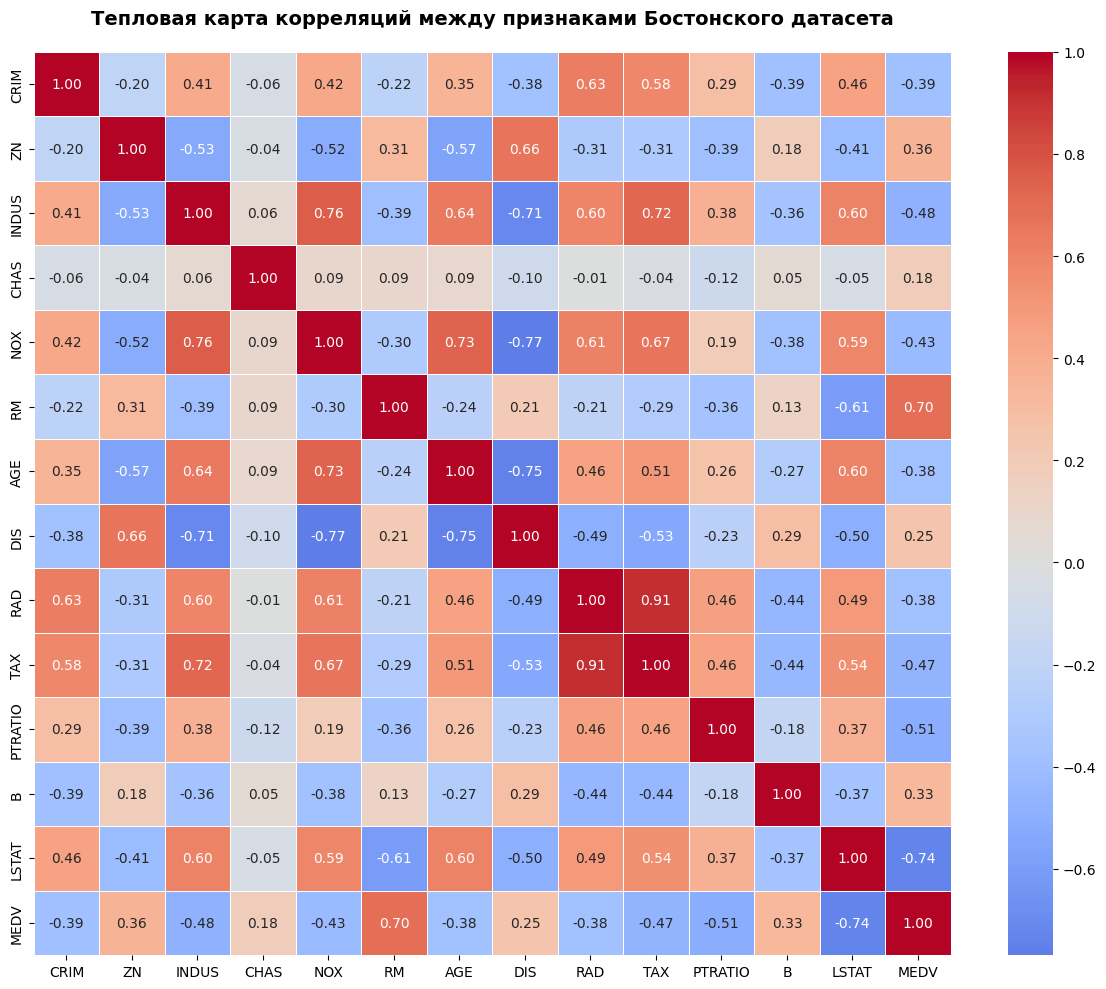


6. ВЫБОР ПРИЗНАКОВ ДЛЯ АНАЛИЗА
Корреляция всех признаков с целевой переменной MEDV:
MEDV       1.000000
RM         0.695360
ZN         0.360445
B          0.333461
DIS        0.249929
CHAS       0.175260
AGE       -0.376955
RAD       -0.381626
CRIM      -0.388305
NOX       -0.427321
TAX       -0.468536
INDUS     -0.483725
PTRATIO   -0.507787
LSTAT     -0.737663
Name: MEDV, dtype: float64

ВЫБРАНО 6 ПРИЗНАКОВ (топ по модулю корреляции):
  LSTAT: -0.738 ↓
  RM: 0.695 ↑ 
  PTRATIO: -0.508 ↓
  INDUS: -0.484 ↓
  TAX: -0.469 ↓
  NOX: -0.427 ↓

7. ПОСТРОЕНИЕ ДИАГРАММ РАССЕЯНИЯ


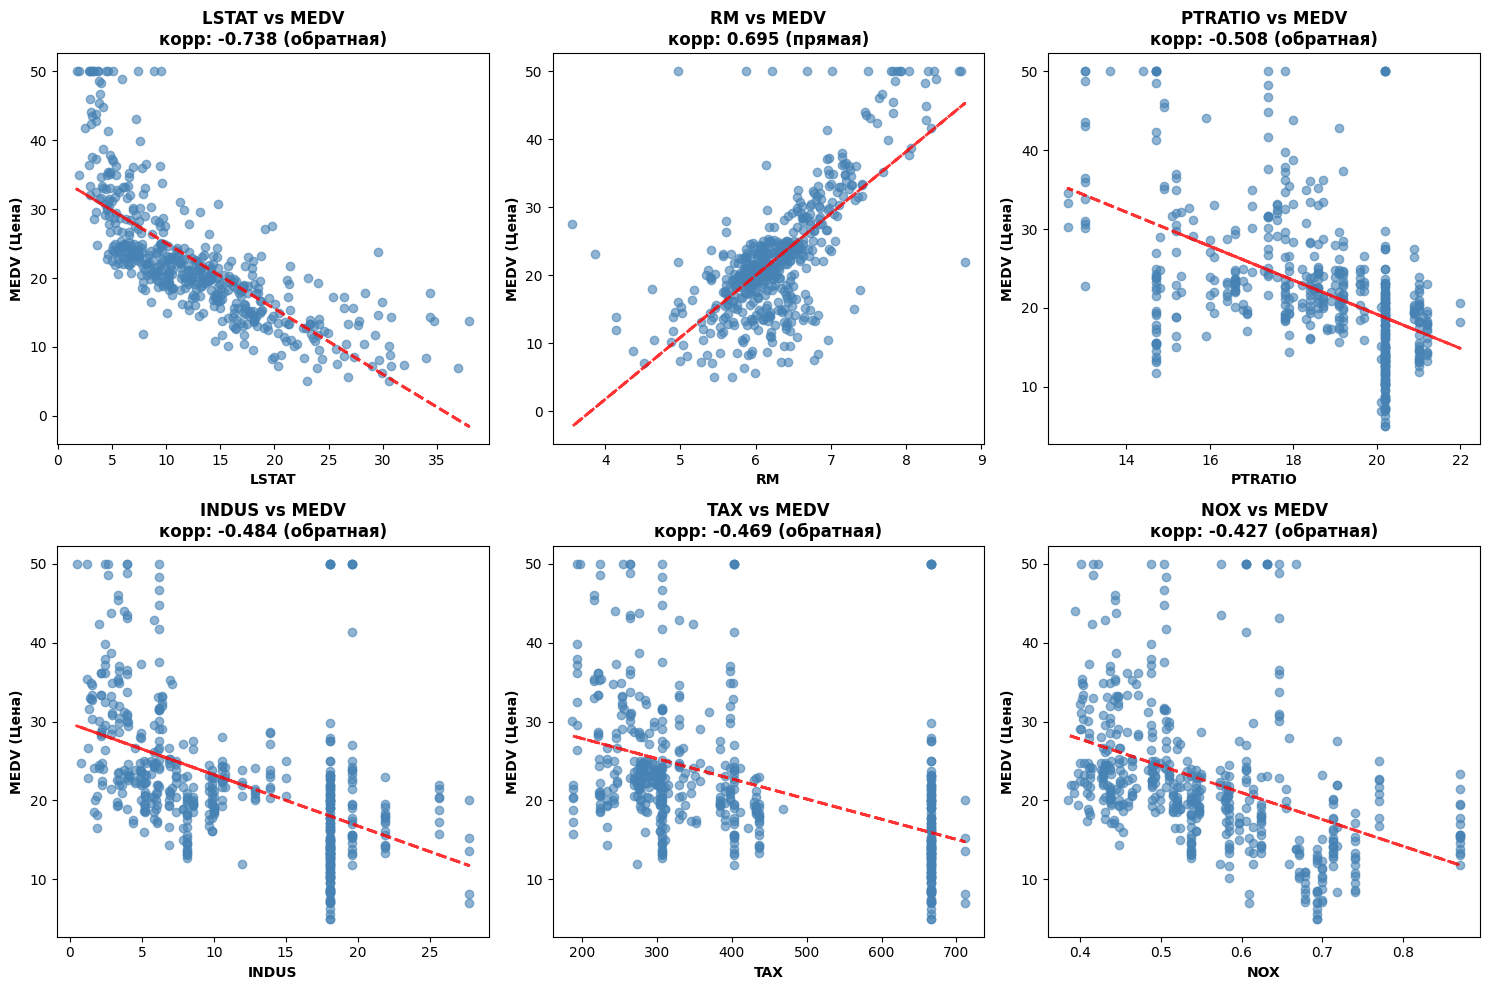


8. ВИЗУАЛЬНАЯ ПРОВЕРКА ЗАВИСИМОСТЕЙ
Анализ диаграмм рассеяния:
LSTAT: -0.738 - ОСТАВИТЬ - сильная линейная зависимость
RM: 0.695 - ОСТАВИТЬ - сильная линейная зависимость
PTRATIO: -0.508 - ОСТАВИТЬ - умеренная зависимость
INDUS: -0.484 - ОСТАВИТЬ - умеренная зависимость
TAX: -0.469 - ОСТАВИТЬ - умеренная зависимость
NOX: -0.427 - ОСТАВИТЬ - умеренная зависимость
Новый список признаков: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX']

Финальный список признаков для модели (6):
  LSTAT: -0.738 (обратная)
  RM: 0.695 (прямая)
  PTRATIO: -0.508 (обратная)
  INDUS: -0.484 (обратная)
  TAX: -0.469 (обратная)
  NOX: -0.427 (обратная)

9. ФОРМИРОВАНИЕ ПРИЗНАКОВ И ЦЕЛЕВОЙ ПЕРЕМЕННОЙ
Факторные признаки: ['LSTAT', 'RM', 'PTRATIO', 'INDUS', 'TAX', 'NOX']
Размерность X (признаки): (506, 6)
Размерность y (целевая): (506,)
Целевая переменная: MEDV (медианная цена недвижимости в тыс. $)

10. РАЗБИЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ
Разбиение выполнено успешно
Обучающая выборка: 404 (79.8%)
Тестова

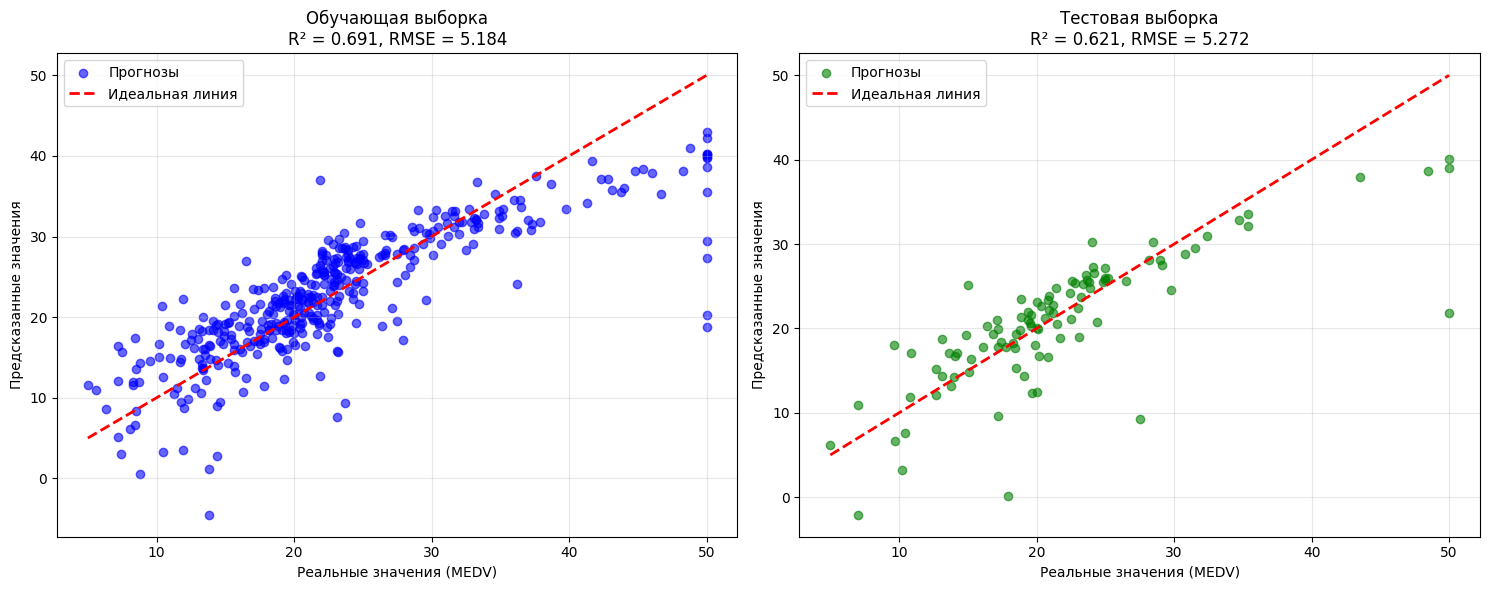

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("ЗАДАНИЕ: ПРОГНОЗИРОВАНИЕ ЦЕНЫ НЕДВИЖИМОСТИ В БОСТОНЕ")

# 1. Загрузка данных
df = pd.read_csv('boston.csv')

# 2. Проверка числового типа данных
print("\n2. ПРОВЕРКА ЧИСЛОВОГО ТИПА ДАННЫХ")

print("\nТипы данных всех столбцов:")
print(df.dtypes)

# Проверяем, что все данные числовые
all_numeric = all(pd.api.types.is_numeric_dtype(df[col]) for col in df.columns)
if all_numeric:
    print("Все данные имеют числовой тип")
else:
    print("Обнаружены нечисловые данные")
    # Преобразуем нечисловые столбцы
    for col in df.columns:
        if not pd.api.types.is_numeric_dtype(df[col]):
            df[col] = pd.to_numeric(df[col], errors='coerce')
            print(f"  Преобразован столбец {col} в числовой тип")

# 3. Проверка отсутствующих данных
print("\n3. ПРОВЕРКА ОТСУТСТВУЮЩИХ ДАННЫХ")

missing_data = df.isnull().sum()

if missing_data.any():
    df = df.fillna(df.median())
    print("\nПропущенные значения заполнены медианами")
else:
    print("\nПропущенные данные отсутствуют")

# 4. Расчет коэффициента корреляции
print("\n4. РАСЧЕТ КОЭФФИЦИЕНТА КОРРЕЛЯЦИИ ДЛЯ ВСЕХ ПАР ПРИЗНАКОВ")

correlation_matrix = df.corr()
print("Корреляционная матрица:")
print(correlation_matrix)

# 5. Построение тепловой карты
print("\n5. ПОСТРОЕНИЕ ТЕПЛОВОЙ КАРТЫ КОРРЕЛЯЦИЙ")

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            fmt='.2f',
            linewidths=0.5)
plt.title('Тепловая карта корреляций между признаками Бостонского датасета',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# 6. Выбор наиболее подходящих признаков
print("\n6. ВЫБОР ПРИЗНАКОВ ДЛЯ АНАЛИЗА")

medv_correlation = correlation_matrix['MEDV'].sort_values(ascending=False)
print("Корреляция всех признаков с целевой переменной MEDV:")
print(medv_correlation)

all_features_corr = medv_correlation.drop('MEDV')

# Сортируем по абсолютному значению (модулю)
sorted_by_abs = all_features_corr.iloc[all_features_corr.abs().argsort()[::-1]]

# Берём от 4 до 6 признаков
n_features = min(6, max(4, len(sorted_by_abs)))
selected_features = list(sorted_by_abs.head(n_features).index)

print(f"\nВЫБРАНО {len(selected_features)} ПРИЗНАКОВ (топ по модулю корреляции):")
for feature in selected_features:
    corr = medv_correlation[feature]
    print(f"  {feature}: {corr:.3f} {'↑ ' if corr > 0 else '↓'}")


# 7. Построение диаграмм рассеяния
print("\n7. ПОСТРОЕНИЕ ДИАГРАММ РАССЕЯНИЯ")

# Определяем layout для subplots
n_features = len(selected_features)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
if n_features == 1:
    axes = [axes]
elif n_rows > 1:
    axes = axes.ravel()
else:
    axes = axes

for i, feature in enumerate(selected_features):
    if n_rows > 1:
        ax = axes[i]
    else:
        ax = axes[i] if n_features > 1 else axes

    ax.scatter(df[feature], df['MEDV'], alpha=0.6, color='steelblue')
    ax.set_xlabel(feature, fontweight='bold')
    ax.set_ylabel('MEDV (Цена)', fontweight='bold')

    corr_value = medv_correlation[feature]
    direction = "прямая" if corr_value > 0 else "обратная"
    ax.set_title(f'{feature} vs MEDV\nкорр: {corr_value:.3f} ({direction})',
                 fontweight='bold')

    # Добавляем линию тренда
    z = np.polyfit(df[feature], df['MEDV'], 1)
    p = np.poly1d(z)
    ax.plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)

# Скрываем пустые subplots
for i in range(n_features, n_rows * n_cols):
    if n_rows > 1:
        axes[i].set_visible(False)
    else:
        if i < len(axes):
            axes[i].set_visible(False)

plt.tight_layout()
plt.show()

# 8. Визуальная проверка зависимостей
print("\n8. ВИЗУАЛЬНАЯ ПРОВЕРКА ЗАВИСИМОСТЕЙ")

print("Анализ диаграмм рассеяния:")
final_features = []
for feature in selected_features:
    corr_value = medv_correlation[feature]

    # Критерии визуальной оценки
    if abs(corr_value) > 0.6:
        decision = "ОСТАВИТЬ - сильная линейная зависимость"
        final_features.append(feature)
    elif abs(corr_value) > 0.4:
        decision = "ОСТАВИТЬ - умеренная зависимость"
        final_features.append(feature)
    else:
        decision = "ИСКЛЮЧИТЬ - слабая зависимость"

    print(f"{feature}: {corr_value:.3f} - {decision}")

# Гарантируем минимум 3 признака
if len(final_features) < 3:
    print(f"\nВНИМАНИЕ: осталось только {len(final_features)} признаков")
    print("Добавляем признаки с наибольшей корреляцией...")

    # Берем топ-3 признака по модулю корреляции
    all_features_corr = medv_correlation.drop('MEDV')
    top_features = all_features_corr[abs(all_features_corr) > 0.3].head(3).index
    final_features = list(top_features)
print(f"Новый список признаков: {final_features}")

print(f"\nФинальный список признаков для модели ({len(final_features)}):")
for feature in final_features:
    corr_value = medv_correlation[feature]
    direction = "прямая" if corr_value > 0 else "обратная"
    print(f"  {feature}: {corr_value:.3f} ({direction})")

# 9. Формирование признаков и целевой переменной
print("\n9. ФОРМИРОВАНИЕ ПРИЗНАКОВ И ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")

X = df[final_features]  # Факторные признаки
y = df['MEDV']          # Целевая переменная

print(f"Факторные признаки: {list(final_features)}")
print(f"Размерность X (признаки): {X.shape}")
print(f"Размерность y (целевая): {y.shape}")
print(f"Целевая переменная: MEDV (медианная цена недвижимости в тыс. $)")

# 10. Разбиение на обучающую и тестовую выборки
print("\n10. РАЗБИЕНИЕ НА ОБУЧАЮЩУЮ И ТЕСТОВУЮ ВЫБОРКИ")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Разбиение выполнено успешно")
print(f"Обучающая выборка: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Тестовая выборка: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"Признаки: {X_train.shape[1]}")

# 11. Обучение линейной регрессии
print("\n11. ОБУЧЕНИЕ ЛИНЕЙНОЙ РЕГРЕССИИ")

model = LinearRegression()
model.fit(X_train, y_train)

print("Модель линейной регрессии обучена")
print("\nПараметры модели:")
print(f"Коэффициенты: {model.coef_}")
print(f"Свободный член: {model.intercept_:.3f}")

print("\nУравнение регрессии:")
equation = f"MEDV = {model.intercept_:.3f}"
for i, (coef, feature) in enumerate(zip(model.coef_, final_features)):
    sign = " + " if coef >= 0 else " - "
    equation += f"{sign}{abs(coef):.3f}*{feature}"
print(equation)

# 12. Получение прогнозных значений
print("\n12. ПОЛУЧЕНИЕ ПРОГНОЗНЫХ ЗНАЧЕНИЙ")

y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

print("Прогнозы получены для обеих выборок")
print(f"Прогнозы на обучающей выборке: {len(y_train_pred)} значений")
print(f"Прогнозы на тестовой выборке: {len(y_test_pred)} значений")

# 13. Расчет метрик качества
print("\n13. РАСЧЕТ МЕТРИК КАЧЕСТВА МОДЕЛИ")

# Коэффициент детерминации (R²)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

# Среднеквадратичная ошибка (RMSE)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print("МЕТРИКИ КАЧЕСТВА:")
print(f"\nОбучающая выборка:")
print(f"  R² (коэффициент детерминации): {r2_train:.4f}")
print(f"  RMSE (среднеквадратичная ошибка): {rmse_train:.4f} тыс. $")

print(f"\nТестовая выборка:")
print(f"  R² (коэффициент детерминации): {r2_test:.4f}")
print(f"  RMSE (среднеквадратичная ошибка): {rmse_test:.4f} тыс. $")

# Анализ результатов
print("АНАЛИЗ РЕЗУЛЬТАТОВ")

# Критерии качества R²
if r2_test > 0.7:
    quality_r2 = "ОТЛИЧНОЕ"
elif r2_test > 0.5:
    quality_r2 = "ХОРОШЕЕ"
elif r2_test > 0.3:
    quality_r2 = "УДОВЛЕТВОРИТЕЛЬНОЕ"
else:
    quality_r2 = "НИЗКОЕ"

# Анализ переобучения
overfitting_gap = r2_train - r2_test
if overfitting_gap < 0.1:
    overfitting_status = "НЕТ ПЕРЕОБУЧЕНИЯ"
elif overfitting_gap < 0.2:
    overfitting_status = "НЕБОЛЬШОЕ ПЕРЕОБУЧЕНИЕ"
else:
    overfitting_status = "ЗНАЧИТЕЛЬНОЕ ПЕРЕОБУЧЕНИЕ"

print(f"Качество модели (R² на тесте): {quality_r2}")
print(f"Переобучение: {overfitting_status} (разница R²: {overfitting_gap:.3f})")
print(f"Средняя ошибка прогноза: {rmse_test:.2f} тыс. $")

# Визуализация реальных vs предсказанных значений
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Обучающая выборка
ax1.scatter(y_train, y_train_pred, alpha=0.6, color='blue', label='Прогнозы')
ax1.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2, label='Идеальная линия')
ax1.set_xlabel('Реальные значения (MEDV)')
ax1.set_ylabel('Предсказанные значения')
ax1.set_title(f'Обучающая выборка\nR² = {r2_train:.3f}, RMSE = {rmse_train:.3f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Тестовая выборка
ax2.scatter(y_test, y_test_pred, alpha=0.6, color='green', label='Прогнозы')
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Идеальная линия')
ax2.set_xlabel('Реальные значения (MEDV)')
ax2.set_ylabel('Предсказанные значения')
ax2.set_title(f'Тестовая выборка\nR² = {r2_test:.3f}, RMSE = {rmse_test:.3f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

